# Data Loader


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from data_loader_00 import load_processed_data, get_combos

In [2]:
train, valid, test, feature_cols = load_processed_data(valid_weeks=8)
print("Train shape:", train.shape)
print("Valid shape:", valid.shape)
print("Test shape:", test.shape)
print("Feature count:", len(feature_cols))
print("Combos:", len(get_combos(train)))

[load] Train=6,270 | Valid=240 | Test=240 | Features=23
Train shape: (6270, 47)
Valid shape: (240, 47)
Test shape: (240, 47)
Feature count: 23
Combos: 30


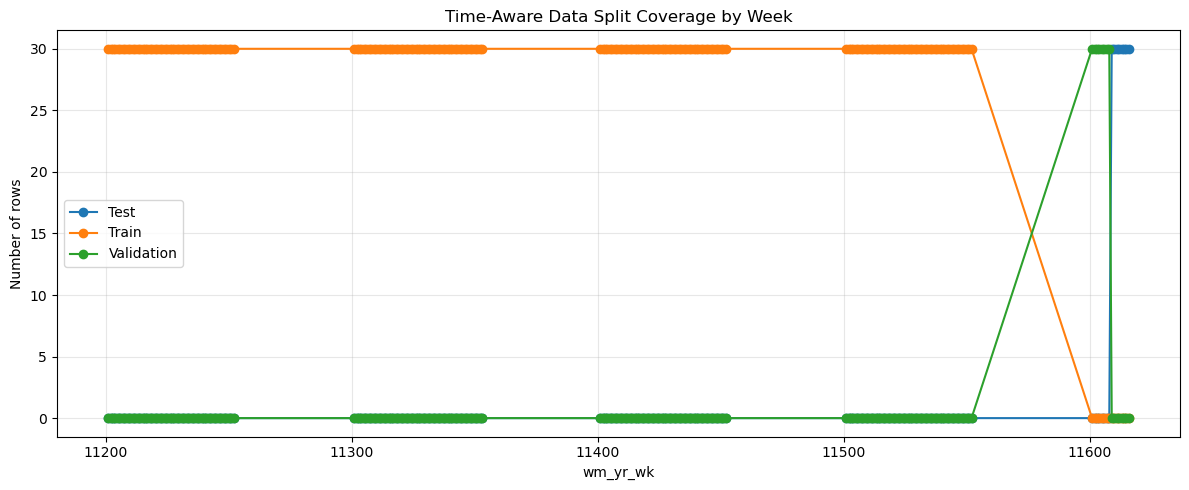

In [3]:
split_summary = pd.concat([
    train[["wm_yr_wk"]].assign(split="Train"),
    valid[["wm_yr_wk"]].assign(split="Validation"),
    test[["wm_yr_wk"]].assign(split="Test"),
], ignore_index=True)

week_counts = (
    split_summary.groupby(["wm_yr_wk", "split"])
    .size()
    .reset_index(name="n_rows")
)

pivot = week_counts.pivot(index="wm_yr_wk", columns="split", values="n_rows").fillna(0)

plt.figure(figsize=(12, 5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)

plt.title("Time-Aware Data Split Coverage by Week")
plt.xlabel("wm_yr_wk")
plt.ylabel("Number of rows")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()